In [1]:
import zipfile
with zipfile.ZipFile('/content/archive (2).zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['spam.csv']


# 1. Imports

In [2]:

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2. Load dataset

In [3]:

# Dataset: "SMS Spam Collection" (Kaggle or UCI ML Repository)
# Columns are typically v1 (label) and v2 (message text)
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3. Class distribution check


label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


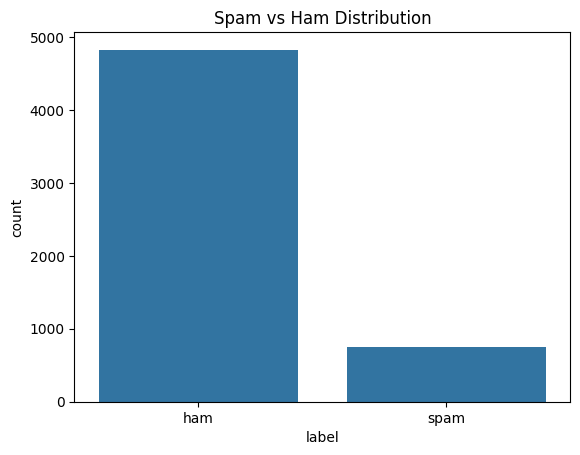

In [4]:

print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Distribution')
plt.show()

## Class Distribution Observation
The dataset is imbalanced — ham messages significantly outnumber spam messages.
This imbalance is important context for evaluation later: accuracy alone will
be misleading, so precision, recall, and F1-score matter more.

# 4. Text preprocessing pipeline

In [5]:

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


# 5. Encode labels

In [7]:

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,clean_message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,0


## TF-IDF Explanation
TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric
vectors by weighing each word based on how often it appears in a message (TF)
against how rare it is across all messages (IDF). Common words across the whole
corpus get down-weighted, while distinctive words specific to a message get
up-weighted — helping the model focus on words that actually distinguish spam
from ham.

# 6, Feature extraction using TF-IDF

In [8]:

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label_num']

# 7. Train/test split

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 4457, Test size: 1115


# 8. Train Model 1: Multinomial Naive Bayes

In [10]:

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

#9. Train Model 2: Logistic Regression (alternative classifier)


In [11]:

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 10. Evaluation function

In [13]:

def evaluate_model(name, y_true, y_pred):
    print(f"===== {name} =====")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 11. Evaluate Naive Bayes

===== Multinomial Naive Bayes =====
Accuracy:  0.9668
Precision: 0.9912
Recall:    0.7584
F1-Score:  0.8593

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



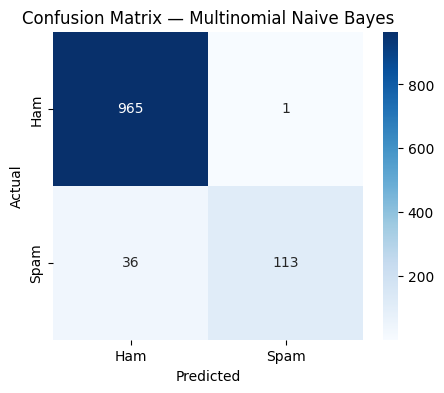

In [14]:

evaluate_model("Multinomial Naive Bayes", y_test, nb_preds)

# 12. Evaluate Logistic Regression

===== Logistic Regression =====
Accuracy:  0.9596
Precision: 0.9906
Recall:    0.7047
F1-Score:  0.8235

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.97      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



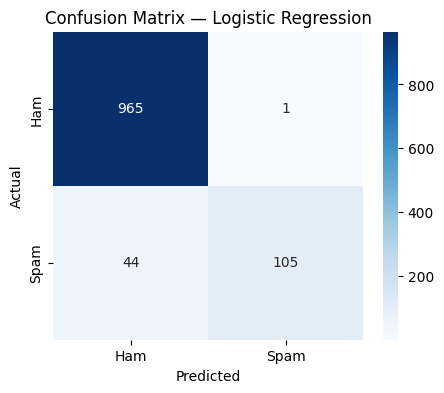

In [15]:

evaluate_model("Logistic Regression", y_test, lr_preds)

## Why Recall Matters for Spam Detection
Recall measures how many actual spam messages the model successfully caught.
In spam detection, missing a spam email (a false negative) is generally more
tolerable than a false positive — flagging a legitimate email as spam risks the
user missing something important (e.g., a job offer or bank notice). However,
recall must still be balanced against precision: too many false positives erode
user trust in the filter. Most production spam filters lean toward higher
precision for this reason, but recall remains critical for measuring how much
spam actually slips through.

# 13.(Bonus) — WordCloud for spam and ham

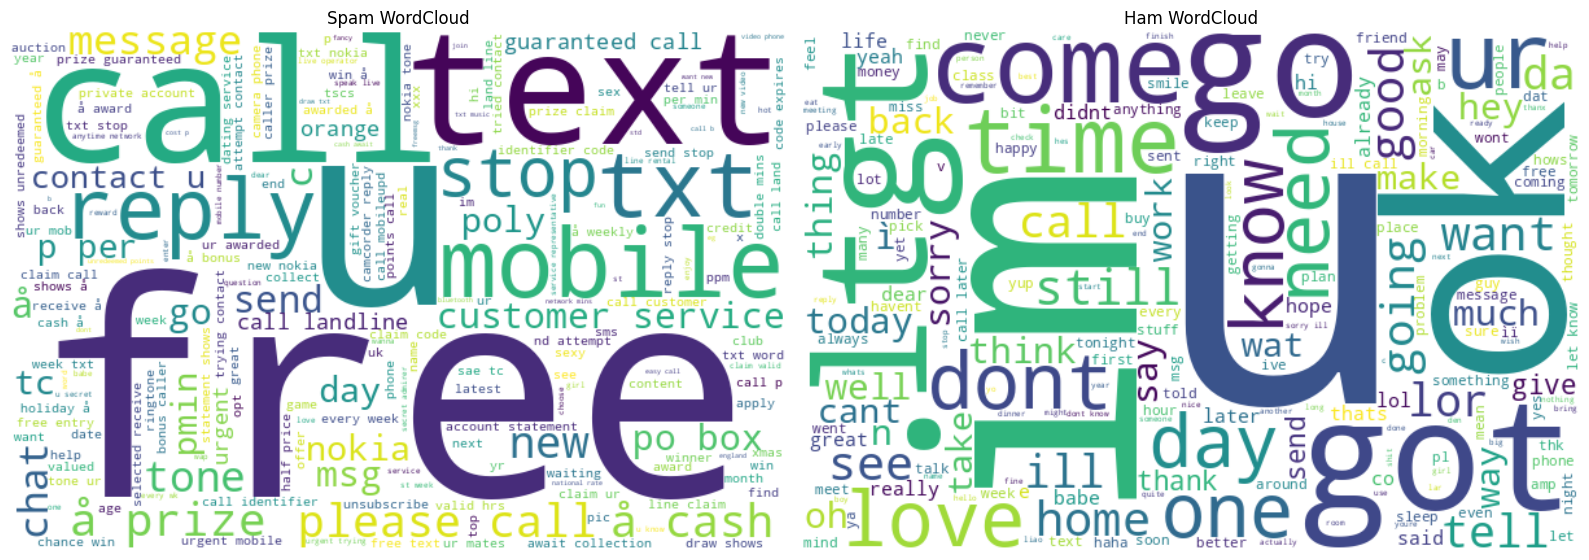

In [16]:

spam_words = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_words = ' '.join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_wc = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title('Spam WordCloud')
axes[0].axis('off')

ham_wc = WordCloud(width=600, height=400, background_color='white').generate(ham_words)
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title('Ham WordCloud')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Conclusion
Both models were evaluated on accuracy, precision, recall, and F1-score:

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Multinomial Naive Bayes | 0.9668 | 0.9912 | 0.7584 | 0.8593 |
| Logistic Regression | 0.9596 | 0.9906 | 0.7047 | 0.8235 |

**Multinomial Naive Bayes performed better overall**, achieving a higher accuracy
(96.68% vs 95.96%) and a notably higher F1-score (0.8593 vs 0.8235). Both models
show very high precision (~99%) — when they predict a message is spam, they are
almost always correct. However, recall is comparatively low for both (75.8% for
NB, 70.5% for LR), meaning a meaningful portion of actual spam messages are still
being missed and classified as ham.

This precision-recall gap reflects the class imbalance in the dataset (~87% ham,
~13% spam) — both models learned to be conservative about labeling something as
spam, favoring precision at some cost to recall. For a real-world deployment, this
trade-off may need adjusting (e.g., via class weighting or a different decision
threshold) depending on whether the priority is catching more spam (higher recall)
or minimizing false alarms on legitimate messages (higher precision).

This approach could serve real-world applications such as email client spam
filters, SMS spam blocking on mobile carriers, or content moderation systems
that need lightweight, fast text classification.